In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)

In [19]:
def quantize_at_bitwidth(tensor, bits):
    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1

    max_abs = np.max(np.abs(tensor))

    if max_abs == 0:
        scale = 1.0
    else:
        scale = max_abs / q_max

    zero_point = 0

    quantized = np.round(tensor / scale)
    quantized = np.clip(quantized, q_min, q_max).astype(np.int32)

    dequantized = quantized.astype(np.float32) * scale

    return quantized, dequantized, scale

In [7]:
def calculate_metrics(original, reconstructed):

    error = original - reconstructed

    mae = np.mean(np.abs(error))
    mse = np.mean(error ** 2)
    max_error = np.max(np.abs(error))

    return mae, mse, max_error

In [9]:
results = []

dequantized_results = {}

for bits in [8, 6, 4]:

    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1
    levels = q_max - q_min + 1

    q, dq, scale = quantize_at_bitwidth(tensor, bits)

    dequantized_results[bits] = dq

    mae, mse, max_error = calculate_metrics(tensor, dq)

    results.append([
        bits,
        q_min,
        q_max,
        levels,
        scale,
        mae,
        mse,
        max_error
    ])

In [11]:
df = pd.DataFrame(
    results,
    columns=[
        "Bits",
        "q_min",
        "q_max",
        "Levels",
        "Scale",
        "MAE",
        "MSE",
        "Max Error"
    ]
)

print(df)

   Bits  q_min  q_max  Levels     Scale       MAE       MSE  Max Error
0     8   -127    127     255  0.018898  0.003701  0.000022   0.007874
1     6    -31     31      63  0.077419  0.015161  0.000363   0.032258
2     4     -7      7      15  0.342857  0.067143  0.007122   0.142857


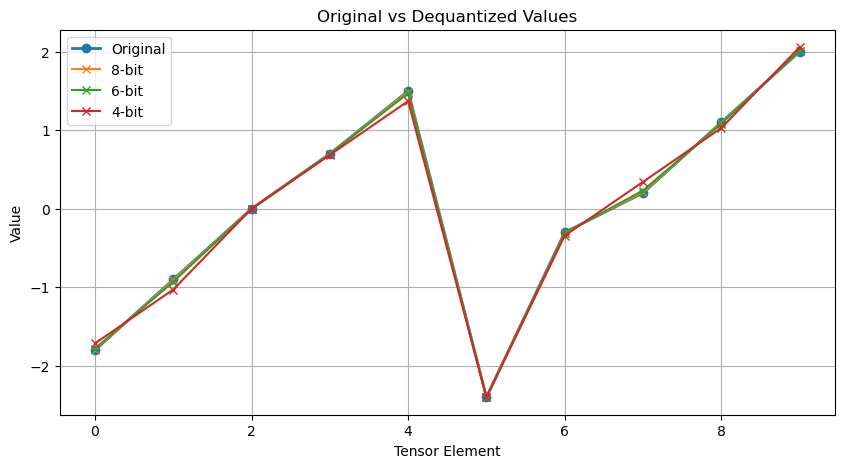

In [13]:
original = tensor.flatten()

x = np.arange(len(original))

plt.figure(figsize=(10,5))

plt.plot(x, original, marker='o', linewidth=2, label='Original')

for bits in [8,6,4]:
    plt.plot(
        x,
        dequantized_results[bits].flatten(),
        marker='x',
        label=f'{bits}-bit'
    )

plt.title("Original vs Dequantized Values")
plt.xlabel("Tensor Element")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

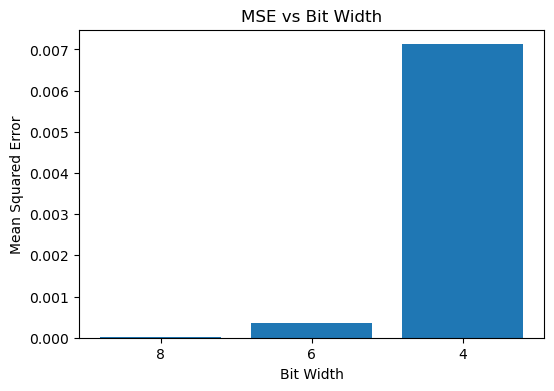

In [15]:
plt.figure(figsize=(6,4))

plt.bar(
    df["Bits"].astype(str),
    df["MSE"]
)

plt.title("MSE vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Mean Squared Error")

plt.show()

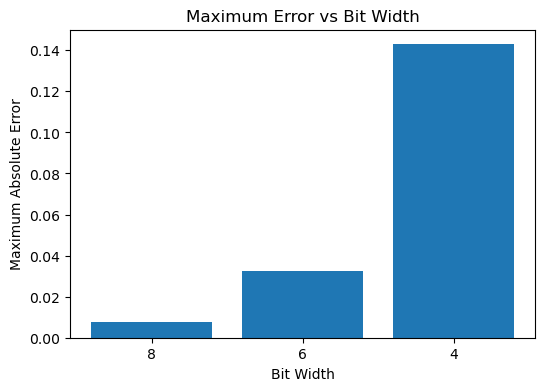

In [17]:
plt.figure(figsize=(6,4))

plt.bar(
    df["Bits"].astype(str),
    df["Max Error"]
)

plt.title("Maximum Error vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Maximum Absolute Error")

plt.show()

# Observations

## 8-bit Quantization

- 8-bit quantization provides the highest precision among the three configurations.
- The reconstructed values closely match the original tensor.
- Both the Mean Absolute Error (MAE) and Mean Squared Error (MSE) are very small.

---

## 6-bit Quantization

- Reducing the bit width to 6 bits decreases the number of available quantization levels from **255 to 63**.
- The scale increases, causing larger rounding errors.
- The reconstructed tensor remains reasonably accurate, but the error is noticeably higher than with 8-bit quantization.

---

## 4-bit Quantization

- 4-bit quantization provides only **15 representable levels**.
- The larger scale significantly reduces numerical precision.
- Reconstruction errors are visibly larger, and the dequantized values deviate more from the original tensor.
- This configuration offers the smallest model size but the lowest numerical accuracy.

---

## Error Analysis

- As the bit width decreases, the quantization scale increases because fewer integer levels are available.
- A larger scale results in coarser quantization intervals, increasing rounding errors.
- Consequently, MAE, MSE, and maximum absolute error increase as the bit width decreases.

---

## Conclusion

- **8-bit quantization** provides the best balance between accuracy and model compression and is widely used in practical deep learning applications.
- **6-bit quantization** offers additional model compression with a moderate increase in quantization error.
- **4-bit quantization** achieves the greatest reduction in memory usage but introduces the highest reconstruction error.
- This experiment demonstrates the trade-off between model size and numerical accuracy: lower bit widths reduce storage requirements but increase quantization error.